
MODULE 1 : DATA INGESTION

FIRST 5 ROWS
   _id                 time    val
0    1  2016-08-18T10:55:00  50.00
1    2  2016-08-18T11:00:00  50.12
2    3  2016-08-18T11:05:00  50.00
3    4  2016-08-18T11:10:00  50.00
4    5  2016-08-18T11:15:00  51.92

DATASET INFO
<class 'pandas.DataFrame'>
DatetimeIndex: 26387 entries, 2016-08-18 10:55:00 to 2017-12-18 08:25:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   val     26387 non-null  float64
dtypes: float64(1)
memory usage: 412.3 KB
None

MODULE 2 : FEATURE ENGINEERING

FEATURES CREATED SUCCESSFULLY

MODULE 3 : CORRELATION ANALYSIS

CORRELATION MATRIX
                   val  Delta_Change  Rolling_Var  Rolling_Mean
val           1.000000      0.347239     0.414052      0.849756
Delta_Change  0.347239      1.000000    -0.007660     -0.013810
Rolling_Var   0.414052     -0.007660     1.000000      0.486401
Rolling_Mean  0.849756     -0.013810     0.486401      1.000000


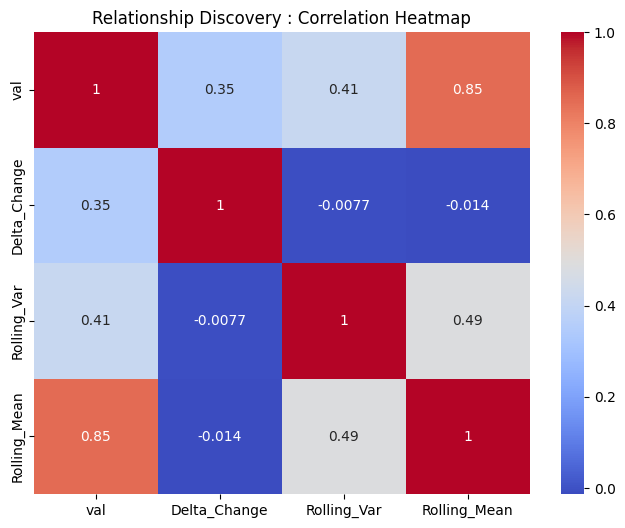


MODULE 4 : UNSUPERVISED DISCOVERY

HIDDEN GROUPS IDENTIFIED

GROUP DISTRIBUTION
Inherent_Group
1.0    14287
2.0     8591
0.0     3509
Name: count, dtype: int64

MODULE 5 : ANOMALY DETECTION

ANOMALY LABELS CREATED

ANOMALY DISTRIBUTION
Anomaly
0    25455
1      932
Name: count, dtype: int64

MODULE 6 : PREDICTIVE CLASSIFICATION

MODEL TRAINED SUCCESSFULLY

PREDICTIONS COMPLETED

MODULE 7 : MODEL EVALUATION

OVERALL ACCURACY
100.00%

CONFUSION MATRIX
[[5082    0]
 [   0  196]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      5082
     Anomaly       1.00      1.00      1.00       196

    accuracy                           1.00      5278
   macro avg       1.00      1.00      1.00      5278
weighted avg       1.00      1.00      1.00      5278


MODULE 8 : VISUALIZATION


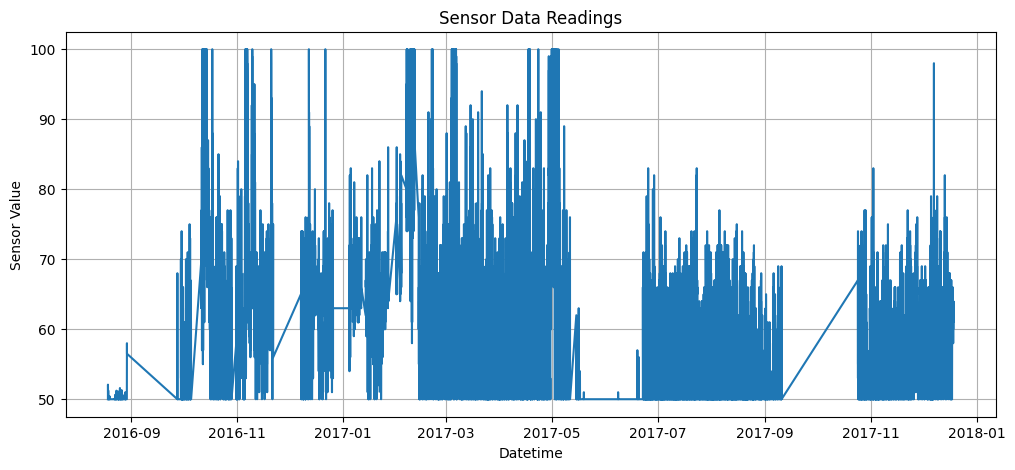

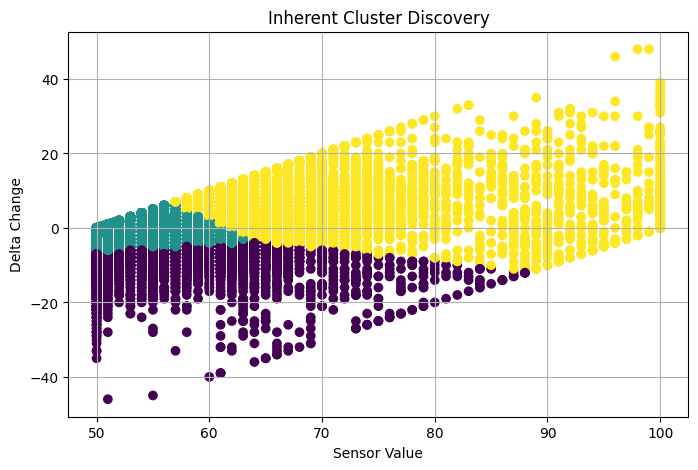

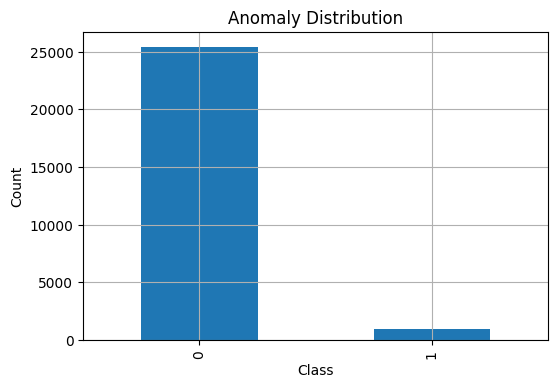


MINED DATA SAVED SUCCESSFULLY

PR_28 PRACTICAL COMPLETED


In [1]:
# ==========================================
# PR_28
# Data Mining Techniques for
# Pattern Discovery and Actionable Insights
# Using Sensor Data Dataset
# ==========================================

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ==========================================
# MODULE 1 :
# DATA INGESTION AND PRE-PROCESSING
# ==========================================

print("\n===================================")
print("MODULE 1 : DATA INGESTION")
print("===================================")

"""
DEFINITION:
Data ingestion converts raw sensor data
into structured analytical format.
"""

# ---------- LOAD DATASET ----------

df = pd.read_csv("sensor_data.csv")

print("\nFIRST 5 ROWS")
print(df.head())

# ---------- DATETIME CONVERSION ----------

df['time'] = pd.to_datetime(
    df['time'],
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# ---------- SET DATETIME INDEX ----------

df = df.set_index('time')

# Sort sequentially
df = df.sort_index()

# ---------- CONVERT SENSOR VALUES ----------

df['val'] = pd.to_numeric(
    df['val'],
    errors='coerce'
)

# Remove invalid sensor values
df = df.dropna(subset=['val'])

# Keep required column
df = df[['val']]

print("\nDATASET INFO")
print(df.info())


# ==========================================
# MODULE 2 :
# FEATURE ENGINEERING
# ==========================================

print("\n===================================")
print("MODULE 2 : FEATURE ENGINEERING")
print("===================================")

"""
DEFINITION:
Feature engineering extracts hidden
patterns from raw sensor readings.
"""

# ---------- DELTA CHANGE ----------

"""
Delta_Change measures
speed of sensor variation.
"""

df['Delta_Change'] = (
    df['val']
    .diff()
    .fillna(0)
)

# ---------- ROLLING VARIANCE ----------

"""
Rolling_Var measures
signal stability.
"""

df['Rolling_Var'] = (
    df['val']
    .rolling(window=10)
    .var()
    .fillna(0)
)

# ---------- ROLLING MEAN ----------

"""
Rolling_Mean represents
local average behavior.
"""

df['Rolling_Mean'] = (
    df['val']
    .rolling(window=10)
    .mean()
    .fillna(0)
)

print("\nFEATURES CREATED SUCCESSFULLY")


# ==========================================
# MODULE 3 :
# RELATIONSHIP DISCOVERY
# ==========================================

print("\n===================================")
print("MODULE 3 : CORRELATION ANALYSIS")
print("===================================")

"""
DEFINITION:
Correlation analysis discovers
relationships between variables.
"""

# ---------- CORRELATION MATRIX ----------

corr_matrix = df.corr()

print("\nCORRELATION MATRIX")
print(corr_matrix)

# ---------- HEATMAP VISUALIZATION ----------

plt.figure(figsize=(8,6))

sns.heatmap(

    corr_matrix,

    annot=True,

    cmap='coolwarm'

)

plt.title(
    "Relationship Discovery : Correlation Heatmap"
)

plt.show()


# ==========================================
# MODULE 4 :
# UNSUPERVISED CLUSTERING
# ==========================================

print("\n===================================")
print("MODULE 4 : UNSUPERVISED DISCOVERY")
print("===================================")

"""
DEFINITION:
K-Means clustering discovers
hidden operational groups
inside the sensor dataset.
"""

# ---------- FEATURE MATRIX ----------

X_cluster = df[[
    'val',
    'Delta_Change'
]].dropna()

# ---------- FEATURE STANDARDIZATION ----------

"""
Standardization ensures all features
contribute equally to distance calculation.
"""

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

# ---------- KMEANS CLUSTERING ----------

kmeans = KMeans(

    n_clusters=3,

    init='k-means++',

    n_init=10,

    random_state=42

)

# ---------- ASSIGN INHERENT GROUPS ----------

df.loc[
    X_cluster.index,
    'Inherent_Group'
] = kmeans.fit_predict(X_scaled)

print("\nHIDDEN GROUPS IDENTIFIED")

print("\nGROUP DISTRIBUTION")
print(
    df['Inherent_Group']
    .value_counts()
)

# ==========================================
# MODULE 5 :
# ANOMALY DETECTION
# ==========================================

print("\n===================================")
print("MODULE 5 : ANOMALY DETECTION")
print("===================================")

"""
DEFINITION:
Anomaly detection identifies
critical abnormal sensor behavior.
"""

# ---------- CREATE ANOMALY LABEL ----------

threshold = (

    df['val'].mean()

    + 2 * df['val'].std()

)

df['Anomaly'] = (

    df['val'] > threshold

).astype(int)

print("\nANOMALY LABELS CREATED")

print("\nANOMALY DISTRIBUTION")
print(
    df['Anomaly']
    .value_counts()
)


# ==========================================
# MODULE 6 :
# PREDICTIVE CLASSIFICATION
# ==========================================

print("\n===================================")
print("MODULE 6 : PREDICTIVE CLASSIFICATION")
print("===================================")

"""
DEFINITION:
Random Forest predicts future
abnormal operational conditions.
"""

# ---------- FINAL FEATURE MATRIX ----------

X = df[[
    'val',
    'Delta_Change',
    'Rolling_Var',
    'Rolling_Mean',
    'Inherent_Group'
]]

# ---------- TARGET VARIABLE ----------

y = df['Anomaly']

# ---------- REMOVE NULL VALUES ----------

combined = pd.concat(
    [X, y],
    axis=1
).dropna()

X = combined.drop(
    columns=['Anomaly']
)

y = combined['Anomaly']

# ---------- TRAIN TEST SPLIT ----------

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

# ---------- RANDOM FOREST MODEL ----------

clf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

# ---------- MODEL TRAINING ----------

clf.fit(

    X_train,

    y_train

)

print("\nMODEL TRAINED SUCCESSFULLY")

# ---------- PREDICTION ----------

y_pred = clf.predict(X_test)

print("\nPREDICTIONS COMPLETED")


# ==========================================
# MODULE 7 :
# PERFORMANCE EVALUATION
# ==========================================

print("\n===================================")
print("MODULE 7 : MODEL EVALUATION")
print("===================================")

"""
DEFINITION:
Evaluation metrics validate
mining model performance.
"""

# ---------- ACCURACY SCORE ----------

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("\nOVERALL ACCURACY")
print(f"{accuracy:.2%}")

# ---------- CONFUSION MATRIX ----------

print("\nCONFUSION MATRIX")

cm = confusion_matrix(

    y_test,

    y_pred

)

print(cm)

# ---------- CLASSIFICATION REPORT ----------

print("\nCLASSIFICATION REPORT")

report = classification_report(

    y_test,

    y_pred,

    target_names=[
        'Normal',
        'Anomaly'
    ]

)

print(report)


# ==========================================
# MODULE 8 :
# VISUALIZATION
# ==========================================

print("\n===================================")
print("MODULE 8 : VISUALIZATION")
print("===================================")

# ---------- SENSOR DATA PLOT ----------

plt.figure(figsize=(12,5))
plt.plot(
    df.index,
    df['val']
)

plt.title("Sensor Data Readings")
plt.xlabel("Datetime")
plt.ylabel("Sensor Value")
plt.grid(True)
plt.show()

# ---------- CLUSTER VISUALIZATION ----------

plt.figure(figsize=(8,5))
plt.scatter(
    df['val'],
    df['Delta_Change'],
    c=df['Inherent_Group']
)

plt.title("Inherent Cluster Discovery")
plt.xlabel("Sensor Value")
plt.ylabel("Delta Change")
plt.grid(True)
plt.show()

# ---------- ANOMALY DISTRIBUTION ----------

plt.figure(figsize=(6,4))

df['Anomaly'].value_counts().plot(
    kind='bar'
)

plt.title("Anomaly Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# ==========================================
# SAVE FINAL MINED DATA
# ==========================================

df.to_csv(
    "mined_sensor_data.csv"
)

print("\nMINED DATA SAVED SUCCESSFULLY")


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_28 PRACTICAL COMPLETED")
print("===================================")